# World Cup 2026 Predictor - Power Rankings & Odds Comparison

This notebook compares model predictions with bookmaker odds.

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import PROCESSED_DIR, RAW_DIR
from src.helpers import normalize_team_name

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Model Predictions

In [8]:
results_path = PROCESSED_DIR / 'tournament_probabilities.csv'
if results_path.exists():
    results = pd.read_csv(results_path)
    print(f'Loaded {len(results)} team predictions')
else:
    print('Tournament predictions not found. Run simulation first.')

Loaded 48 team predictions


## 2. Load Bookmaker Odds

In [9]:
odds_path = RAW_DIR / 'odds_outright.csv'
if odds_path.exists():
    odds = pd.read_csv(odds_path)
    odds['team'] = odds['team'].apply(normalize_team_name)
    print(f'Loaded odds for {len(odds["team"].unique())} teams')
    print(f'Bookmakers: {odds["bookmaker"].unique()}')
else:
    print('Odds data not found. Set ODDS_API_KEY and run scrape_odds.py.')

Loaded odds for 20 teams
Bookmakers: <ArrowStringArray>
['FIFA_RANKING_FALLBACK']
Length: 1, dtype: str


## 3. Compare Model vs Odds

In [10]:
if odds_path.exists() and results_path.exists():
    best_odds = odds.groupby('team')['implied_probability'].max().reset_index()
    best_odds.columns = ['team', 'odds_probability']

    comparison = results.merge(best_odds, on='team', how='left')
    comparison = comparison.dropna(subset=['odds_probability'])
    comparison['difference'] = comparison['prob_winner'] - comparison['odds_probability']
    comparison['value'] = comparison['difference'] > 0.01

    print(f'\nModel vs Odds comparison for {len(comparison)} teams')
    print('\nTop value bets (model > odds):')
    print(comparison.nlargest(10, 'difference')[['team', 'prob_winner', 'odds_probability', 'difference']].to_string(index=False))

    print('\nOverrated teams (odds > model):')
    print(comparison.nsmallest(10, 'difference')[['team', 'prob_winner', 'odds_probability', 'difference']].to_string(index=False))


Model vs Odds comparison for 19 teams

Top value bets (model > odds):
         team  prob_winner  odds_probability  difference
       Mexico        0.079          0.036289    0.042711
  Switzerland        0.055          0.030097    0.024903
United States        0.051          0.033457    0.017543
      Germany        0.038          0.046200   -0.008200
        Japan        0.022          0.031881   -0.009881
       Brazil        0.040          0.053700   -0.013700
      Uruguay        0.017          0.033767   -0.016767
     Colombia        0.020          0.038316   -0.018316
      Belgium        0.029          0.047719   -0.018719
         Iran        0.007          0.025842   -0.018842

Overrated teams (odds > model):
       team  prob_winner  odds_probability  difference
  Argentina        0.041          0.093735   -0.052735
      Spain        0.040          0.092543   -0.052543
    England        0.024          0.073275   -0.049275
     France        0.046          0.090706   -0.0

## 4. Visualization

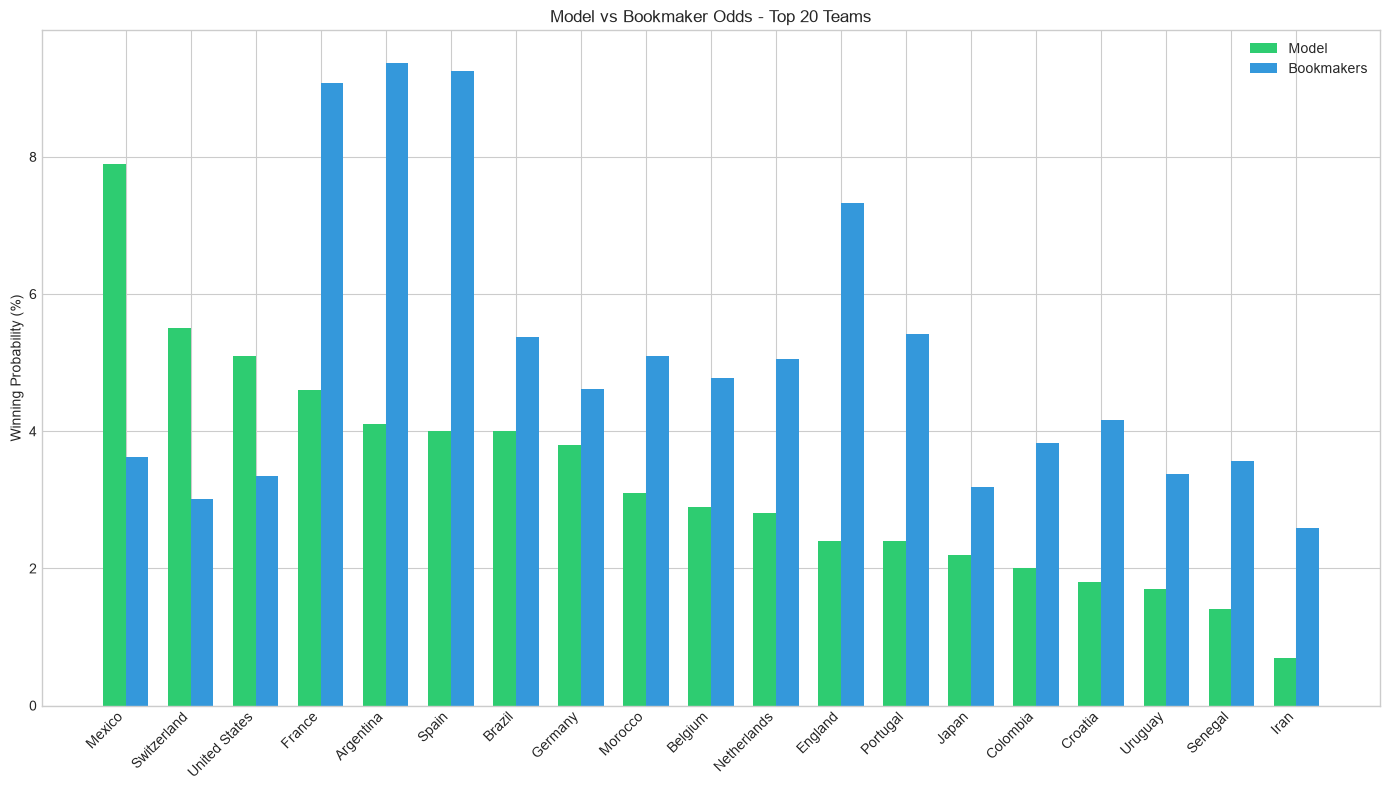

In [11]:
if odds_path.exists() and results_path.exists():
    top_20 = comparison.nlargest(20, 'prob_winner')

    fig, ax = plt.subplots(figsize=(14, 8))

    x = np.arange(len(top_20))
    width = 0.35

    ax.bar(x - width/2, top_20['prob_winner'] * 100, width, label='Model', color='#2ecc71')
    ax.bar(x + width/2, top_20['odds_probability'] * 100, width, label='Bookmakers', color='#3498db')

    ax.set_xticks(x)
    ax.set_xticklabels(top_20['team'], rotation=45, ha='right')
    ax.set_ylabel('Winning Probability (%)')
    ax.set_title('Model vs Bookmaker Odds - Top 20 Teams')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Power Rankings with Confidence Intervals

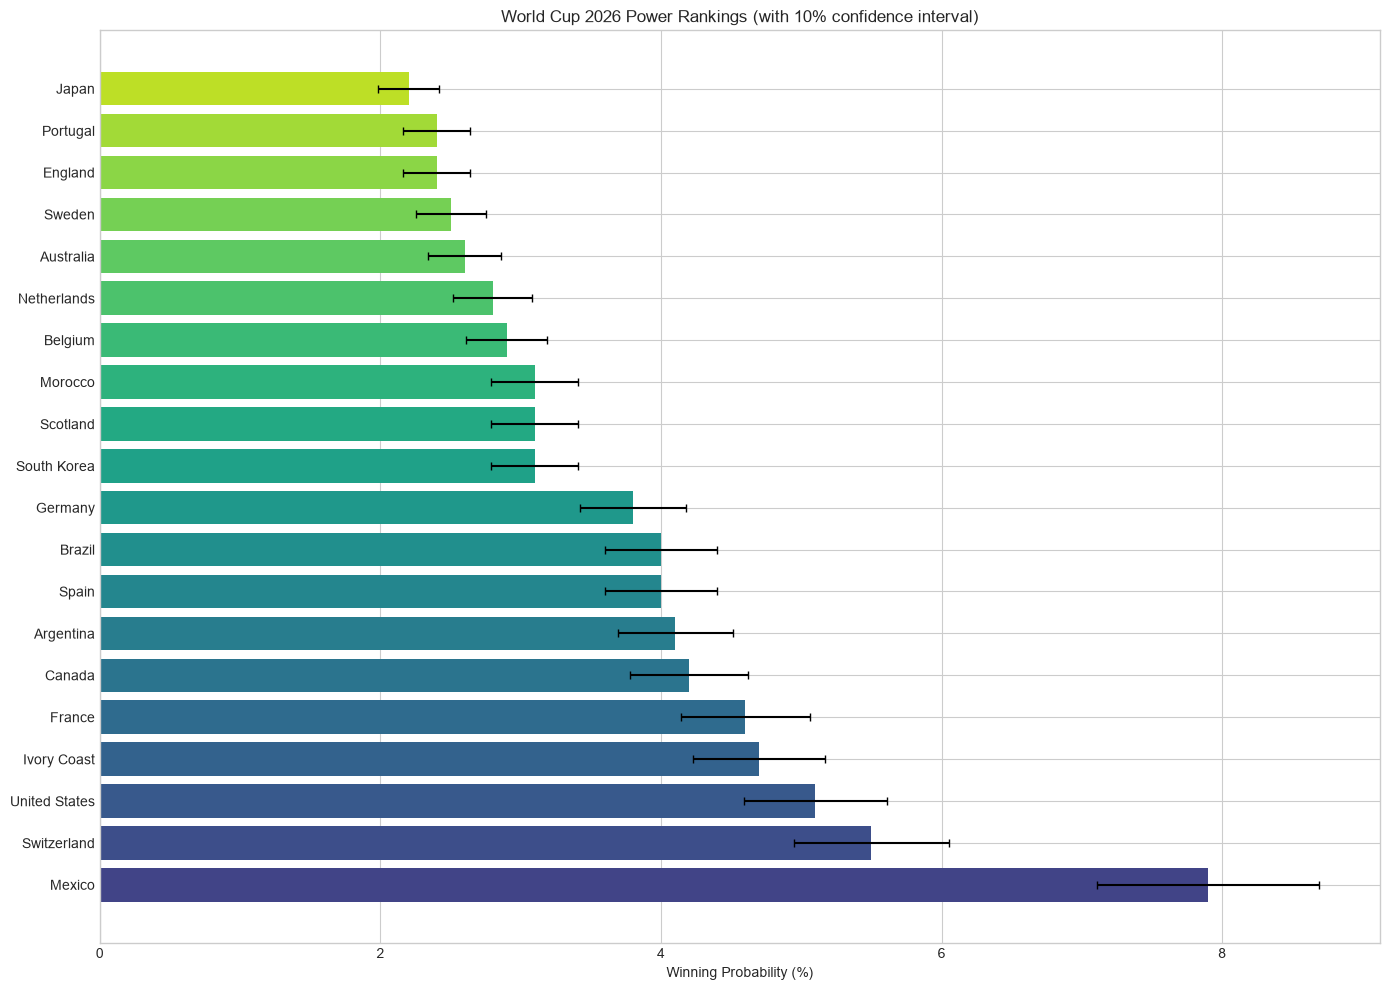

In [12]:
if results_path.exists():
    fig, ax = plt.subplots(figsize=(14, 10))

    top_20 = results.nlargest(20, 'prob_winner')

    bars = ax.barh(
        range(len(top_20)),
        top_20['prob_winner'] * 100,
        xerr=top_20['prob_winner'] * 100 * 0.1,
        color=plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20))),
        capsize=3
    )

    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['team'])
    ax.set_xlabel('Winning Probability (%)')
    ax.set_title('World Cup 2026 Power Rankings (with 10% confidence interval)')
    plt.tight_layout()
    plt.show()